In [13]:
import librosa
import pandas as pd
import numpy as np
import os
import time


In [2]:
# Carga los CSVs
esc = pd.read_csv("esc50.csv")
urban = pd.read_csv("UrbanSound8K.csv")

# Revisa estructura
print("=== ESC-50 ===")
print(esc.head(3))
print(esc.shape)

print("\n=== UrbanSound8K ===")
print(urban.head(3))
print(urban.shape)

=== ESC-50 ===
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
(2000, 7)

=== UrbanSound8K ===
      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
(8732, 8)


In [14]:
ruta_base = "/Users/luisenriquearreolasilva/Desktop/proyecto sitemas inteligentes/UrbanSound8K"

def extraer_features(ruta):
    try:
        y, sr = librosa.load(ruta, sr=22050, duration=4)
        rms = np.sqrt(np.mean(y**2))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
        return [rms, zcr, centroid] + list(mfccs)
    except:
        return None

columnas = ["rms", "zcr", "centroid"] + [f"mfcc_{i}" for i in range(1, 14)]

resultados = []
total = len(urban)
start = time.time()

for i, row in urban.iterrows():
    features = extraer_features(row["ruta"])
    if features:
        entrada = [row["slice_file_name"], row["class"]] + features
        resultados.append(entrada)
    
    if i % 500 == 0:
        print(f"{i}/{total} archivos procesados...")

df_features = pd.DataFrame(resultados, columns=["archivo", "clase"] + columnas)
df_features.to_csv("urban_features.csv", index=False)

print(f"Listo. Tiempo total: {(time.time()-start)/60:.1f} minutos")
print(df_features.head())

0/8732 archivos procesados...
500/8732 archivos procesados...
1000/8732 archivos procesados...
1500/8732 archivos procesados...
2000/8732 archivos procesados...
2500/8732 archivos procesados...
3000/8732 archivos procesados...
3500/8732 archivos procesados...


/Users/luisenriquearreolasilva/envpython/lib/python3.14/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(


4000/8732 archivos procesados...
4500/8732 archivos procesados...
5000/8732 archivos procesados...
5500/8732 archivos procesados...
6000/8732 archivos procesados...
6500/8732 archivos procesados...
7000/8732 archivos procesados...
7500/8732 archivos procesados...
8000/8732 archivos procesados...


/Users/luisenriquearreolasilva/envpython/lib/python3.14/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/Users/luisenriquearreolasilva/envpython/lib/python3.14/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


8500/8732 archivos procesados...
Listo. Tiempo total: 1.5 minutos
              archivo             clase       rms       zcr     centroid  \
0    100032-3-0-0.wav          dog_bark  0.164392  0.123465  2089.849952   
1  100263-2-0-117.wav  children_playing  0.004148  0.138779  2137.808991   
2  100263-2-0-121.wav  children_playing  0.003071  0.102003  1846.767529   
3  100263-2-0-126.wav  children_playing  0.004994  0.130761  2301.066814   
4  100263-2-0-137.wav  children_playing  0.003266  0.118105  2004.947176   

       mfcc_1      mfcc_2      mfcc_3     mfcc_4     mfcc_5     mfcc_6  \
0 -211.936981   62.581207 -122.813156 -60.745281 -13.893760 -29.789827   
1 -417.005188   99.336624  -42.995586  51.073326   9.853777   7.969693   
2 -452.393158  112.362534  -37.578072  43.195862   8.631845  15.379366   
3 -406.479218   91.196602  -25.043558  42.784519  11.586843   5.054165   
4 -439.638672  103.862244  -42.658787  50.690277  12.209420  15.873465   

      mfcc_7     mfcc_8     mfcc

In [15]:
print("Total de archivos procesados:", len(df_features))
print("Archivos en el CSV original:", len(urban))
print("Clases presentes:", df_features["clase"].unique())
print("¿Valores nulos?", df_features.isnull().sum().sum())

Total de archivos procesados: 8732
Archivos en el CSV original: 8732
Clases presentes: ['dog_bark' 'children_playing' 'car_horn' 'air_conditioner' 'street_music'
 'gun_shot' 'siren' 'engine_idling' 'jackhammer' 'drilling']
¿Valores nulos? 0


In [ ]:
ruta_base = "/Users/luisenriquearreolasilva/Desktop/proyecto sitemas inteligentes/UrbanSound8K"

def extraer_features(ruta):
    try:
        y, sr = librosa.load(ruta, sr=22050, duration=4)
        rms = np.sqrt(np.mean(y**2))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13), axis=1)
        return [rms, zcr, centroid] + list(mfccs)
    except:
        return None

columnas = ["rms", "zcr", "centroid"] + [f"mfcc_{i}" for i in range(1, 14)]

resultados = []
total = len(urban)
start = time.time()

for i, row in urban.iterrows():
    features = extraer_features(row["ruta"])
    if features:
        entrada = [row["slice_file_name"], row["class"]] + features
        resultados.append(entrada)
    
    if i % 500 == 0:
        print(f"{i}/{total} archivos procesados...")

df_features = pd.DataFrame(resultados, columns=["archivo", "clase"] + columnas)
df_features.to_csv("urban_features.csv", index=False)

print(f"Listo. Tiempo total: {(time.time()-start)/60:.1f} minutos")
print(df_features.head())

In [24]:
resultados_esc = []
total_esc = len(esc)
start = time.time()

for i, row in esc.iterrows():
    features = extraer_features(row["ruta"])
    if features:
        entrada = [row["filename"], row["category"]] + features
        resultados_esc.append(entrada)
    
    if i % 200 == 0:
        print(f"{i}/{total_esc} archivos procesados...")

df_esc = pd.DataFrame(resultados_esc, columns=["archivo", "clase"] + columnas)
df_esc.to_csv("esc_features.csv", index=False)

print(f"Listo. Tiempo total: {(time.time()-start)/60:.1f} minutos")
print(df_esc.shape)

0/2000 archivos procesados...
200/2000 archivos procesados...
400/2000 archivos procesados...
600/2000 archivos procesados...
800/2000 archivos procesados...
1000/2000 archivos procesados...
1200/2000 archivos procesados...
1400/2000 archivos procesados...
1600/2000 archivos procesados...
1800/2000 archivos procesados...
Listo. Tiempo total: 0.3 minutos
(2000, 18)


In [27]:
df_total = pd.concat([df_features, df_esc], ignore_index=True)
df_total.to_csv("features_total.csv", index=False)

print("Total de muestras:", len(df_total))
print("Columnas:", df_total.columns.tolist())

Total de muestras: 10732
Columnas: ['archivo', 'clase', 'rms', 'zcr', 'centroid', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13']


In [29]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

X = df_total[["rms", "zcr", "centroid"] + [f"mfcc_{i}" for i in range(1, 14)]]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("Shape después de normalizar:", X_scaled.shape)
print("Min de cada feature (debe ser 0):", X_scaled.min(axis=0).round(2))
print("Max de cada feature (debe ser 1):", X_scaled.max(axis=0).round(2))

Shape después de normalizar: (10732, 16)
Min de cada feature (debe ser 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max de cada feature (debe ser 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


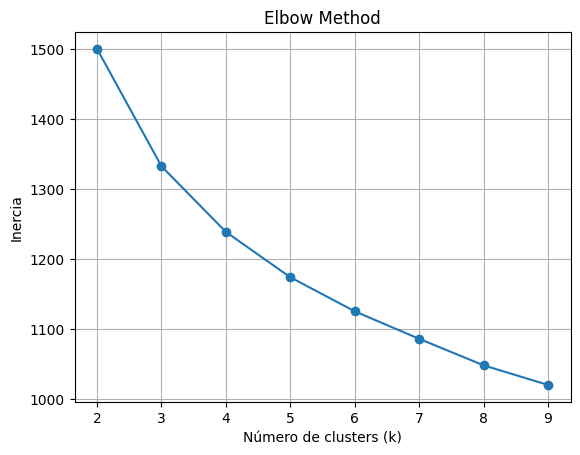

In [30]:
import matplotlib.pyplot as plt

inercias = []
k_valores = range(2, 10)

for k in k_valores:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)

plt.plot(k_valores, inercias, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Elbow Method")
plt.xticks(k_valores)
plt.grid(True)
plt.show()

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Agregar el cluster a tu dataframe
df_total["cluster"] = kmeans.labels_

# Ver cuántas muestras hay en cada cluster
print(df_total["cluster"].value_counts())

cluster
2    5020
0    3761
1    1951
Name: count, dtype: int64


In [32]:
# Promedio de features por cluster
resumen = df_total.groupby("cluster")[["rms", "zcr", "centroid"]].mean()
print(resumen)

              rms       zcr     centroid
cluster                                 
0        0.109669  0.105524  1892.791697
1        0.080699  0.284102  3900.963736
2        0.058411  0.073011  1669.629970


In [33]:
etiquetas = {2: "favorable", 0: "moderado", 1: "no_favorable"}
df_total["concentracion"] = df_total["cluster"].map(etiquetas)

print(df_total["concentracion"].value_counts())

concentracion
favorable       5020
moderado        3761
no_favorable    1951
Name: count, dtype: int64


In [36]:
print("=== FAVORABLE ===")
print(df_total[df_total["concentracion"] == "favorable"]["clase"].value_counts())

=== FAVORABLE ===
clase
engine_idling       671
air_conditioner     648
siren               642
children_playing    619
dog_bark            504
street_music        415
gun_shot            167
jackhammer          166
car_horn            123
drilling            104
door_wood_knock      40
snoring              38
sneezing             35
thunderstorm         35
water_drops          34
mouse_click          33
cat                  33
can_opening          33
drinking_sipping     32
crackling_fire       32
fireworks            30
clock_tick           30
engine               30
glass_breaking       28
coughing             28
frog                 28
keyboard_typing      27
rooster              27
breathing            26
door_wood_creaks     26
footsteps            24
washing_machine      23
wind                 21
insects              21
crow                 20
helicopter           19
dog                  19
brushing_teeth       16
hen                  16
sheep                16
airplane        

In [37]:
print("\n=== MODERADO ===")
print(df_total[df_total["concentracion"] == "moderado"]["clase"].value_counts())


=== MODERADO ===
clase
street_music        550
dog_bark            444
children_playing    339
siren               322
jackhammer          320
car_horn            289
drilling            270
engine_idling       262
air_conditioner     219
gun_shot            180
sea_waves            35
church_bells         34
train                33
cow                  30
clapping             26
laughing             25
hen                  24
pig                  23
airplane             23
dog                  21
sheep                21
chainsaw             18
crow                 17
wind                 17
vacuum_cleaner       17
helicopter           17
crying_baby          15
insects              15
hand_saw             14
toilet_flush         14
rooster              11
breathing            11
frog                 10
washing_machine      10
coughing             10
footsteps             9
door_wood_creaks      7
engine                7
cat                   7
fireworks             6
thunderstorm    

In [38]:
print("\n=== NO FAVORABLE ===")
print(df_total[df_total["concentracion"] == "no_favorable"]["clase"].value_counts())


=== NO FAVORABLE ===
clase
drilling            626
jackhammer          514
air_conditioner     133
engine_idling        67
car_horn             57
dog_bark             52
children_playing     42
street_music         35
rain                 33
clock_alarm          28
crickets             28
gun_shot             27
pouring_water        24
chirping_birds       23
vacuum_cleaner       23
brushing_teeth       22
toilet_flush         22
hand_saw             20
chainsaw             19
crying_baby          16
keyboard_typing      12
glass_breaking       12
clapping             10
door_wood_creaks      7
washing_machine       7
crackling_fire        7
can_opening           7
footsteps             7
clock_tick            5
siren                 5
mouse_click           5
pig                   5
helicopter            4
fireworks             4
water_drops           4
insects               4
sneezing              3
sheep                 3
engine                3
crow                  3
breathing   

In [39]:
df_total.to_csv("features_clustered.csv", index=False)
print("Guardado. Shape:", df_total.shape)

Guardado. Shape: (10732, 20)


In [42]:
resumen_interpretable = df_total.groupby("concentracion")[["rms", "zcr", "centroid"]].mean()

# Convertir RMS a dB
resumen_interpretable["db"] = 20 * np.log10(resumen_interpretable["rms"])

# ZCR ya está en proporción, convertir a porcentaje
resumen_interpretable["zcr_pct"] = resumen_interpretable["zcr"] * 100

# Centroid ya está en Hz, solo redondeamos
resumen_interpretable["centroid_hz"] = resumen_interpretable["centroid"].round(0)

# Tabla final legible
print(resumen_interpretable[["db", "zcr_pct", "centroid_hz"]].round(2))

                      db  zcr_pct  centroid_hz
concentracion                                 
favorable     -24.670000     7.30       1670.0
moderado      -19.200001    10.55       1893.0
no_favorable  -21.860001    28.41       3901.0


In [43]:
resumen_interpretable[["db", "zcr_pct", "centroid_hz"]].round(2).to_csv("resumen_clusters.csv")
print("Guardado.")

Guardado.


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Features y etiquetas
X = df_total[["rms", "zcr", "centroid"] + [f"mfcc_{i}" for i in range(1, 14)]]
y = df_total["concentracion"]

# Normalizar
X_scaled = scaler.transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8585, 16)
Test: (2147, 16)


In [45]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   favorable       0.99      0.99      0.99      1008
    moderado       1.00      0.97      0.99       751
no_favorable       0.97      1.00      0.98       388

    accuracy                           0.99      2147
   macro avg       0.98      0.99      0.99      2147
weighted avg       0.99      0.99      0.99      2147



In [46]:
mlp2 = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    max_iter=500,
    random_state=42
)

mlp2.fit(X_train, y_train)

y_pred2 = mlp2.predict(X_test)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

   favorable       0.95      1.00      0.97      1008
    moderado       1.00      0.92      0.96       751
no_favorable       0.97      0.98      0.98       388

    accuracy                           0.97      2147
   macro avg       0.97      0.97      0.97      2147
weighted avg       0.97      0.97      0.97      2147



In [47]:
import joblib

joblib.dump(mlp, "modelo_concentracion.pkl")
joblib.dump(scaler, "scaler_concentracion.pkl")

print("Modelo y scaler guardados.")

Modelo y scaler guardados.
